In [1]:
import math

from common import *
from experiment import *
from data import RawData, PlottableData

In [2]:
def TREATMENTS(protocol='picoquic', prefix='quic'):
    network_options = ['--freq-ms', '25', '--freq-pkts', '8', '--network-statistics']
    return [
        Treatment(protocol, label=f'picoquic', network_options=network_options, protocol_options=[]),
        Treatment(protocol, label=f'picoquic_sidekick_30ms', network_options=network_options + ['--proxy', 'sidekick'], protocol_options=['--ack-delay', '30', '--client-quacker']),
        Treatment(protocol, label=f'picoquic_split', network_options=network_options + ['--proxy', 'picoquic'], protocol_options=[]),
    ]

def BBR_TREATMENTS(cca):
    treatments = TREATMENTS()
    for treatment in treatments:
        treatment._label += f'_{cca}'
        treatment._protocol_options += ['-cca', cca]
    return treatments

LOSS1_VALUES = [0, 1, 2, 3, 4, 5, 6, 7, 8]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=loss1, loss2=0)
        for loss1 in LOSS1_VALUES[:n]
    ]

def DATA_SIZES(bottleneck_bw=20):
    return [bottleneck_bw * 1250000]

# Collect data for experiments

In [3]:
# NOTE: We have to run one trial at a time with the sidekick since it can only handle one connection at a time,
# and it decides which connection to handle by the first UDP packet it observes
for i in range(1, 2):
    exp = Experiment(num_trials=i, treatments=BBR_TREATMENTS('bbr1'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True)
    exp = Experiment(num_trials=i, treatments=BBR_TREATMENTS('bbr'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True)
    exp = Experiment(num_trials=i, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True, max_networks={'picoquic': 7})

27
14.38150930404663mulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 0 --loss2 0 -t 1 --label picoquic_bbr1 --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -cca bbr1 -n 25000000 
14.329559803009033ulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 1 --loss2 0 -t 1 --label picoquic_bbr1 --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -cca bbr1 -n 25000000 
15.031204462051392ulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 2 --loss2 0 -t 1 --label picoquic_bbr1 --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -cca bbr1 -n 25000000 
14.969661951065063ulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 3 --loss2 0 -t 1 --label picoquic_bbr1 --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -cca bbr1 -n 25000000 
15.394587516784668ulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 -t 1 --label picoquic_bbr1 --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -cca bbr1 -n 25000000 
15.185207843780518ulation/main.py --b

SystemExit: 1

/home/ubuntu/sidekick-downloads/env/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3557: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [4]:
%tb

SystemExit: 1

In [5]:
n = 1
exp = Experiment(num_trials=n, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
picoquic_raw_data = RawData(exp, execute=False, max_networks={'picoquic': 7})
exp = Experiment(num_trials=n, treatments=BBR_TREATMENTS('bbr1'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
bbr1_raw_data = RawData(exp, execute=False)
exp = Experiment(num_trials=n, treatments=BBR_TREATMENTS('bbr'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
bbr3_raw_data = RawData(exp, execute=False)

MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 0 --loss2 0 -t 1 --label picoquic --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 1 --loss2 0 -t 1 --label picoquic --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 2 --loss2 0 -t 1 --label picoquic --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 3 --loss2 0 -t 1 --label picoquic --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 -t 1 --label picoquic --freq-ms 25 --freq-pkts 8 --network-statistics picoquic -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 -

In [5]:
# exp = Experiment(num_trials=1, treatments=TREATMENTS('quic', 'chromium'), network_settings=NETWORK_SETTINGS(n=10), data_sizes=DATA_SIZES)
# chromium_raw_data = RawData(exp, execute=True)
# exp = Experiment(num_trials=10, treatments=TREATMENTS('quiche', 'cloudflare'), network_settings=NETWORK_SETTINGS, data_sizes=DATA_SIZES)
# tcp_raw_data = RawData(exp, execute=True)
# exp = Experiment(num_trials=10, treatments=TREATMENTS('tcp', 'tcp'), network_settings=NETWORK_SETTINGS, data_sizes=DATA_SIZES)
# tcp_raw_data = RawData(exp, execute=True)

# Plot network metrics

In [6]:
def plot_loss_vs_metric_line(data, title, ylabel, delta=25):
    plt.figure(figsize=(6, 4))
    
    labels = data.treatments
    assert len(data.data_sizes) == 1
    data_size = data.data_sizes[0]

    # Plot each label
    for label in labels:
        xs = []
        ys_raw = []

        for network in data.network_settings:
            if data_size not in data.data[label][network]:
                continue
            network_setting = data.exp.get_network_setting(network)
            xs.append(float(network_setting.settings['loss1']))
            ys_raw.append(data.data[label][network][data_size])

        ys = [y.p(50) for y in ys_raw]
        yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
        yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
        plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker='.', capsize=5, label=label)

    plt.title(title)
    plt.xlabel('Loss % near data receiver')
    plt.ylabel(ylabel)
    plt.grid()
    plt.xlim(0)
    plt.ylim(0)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    plt.show()

## Throughput

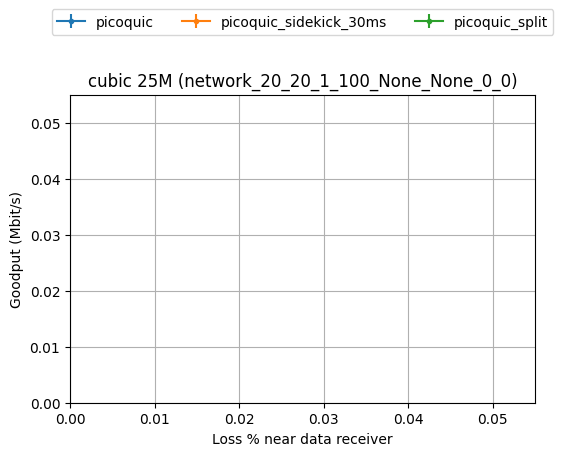

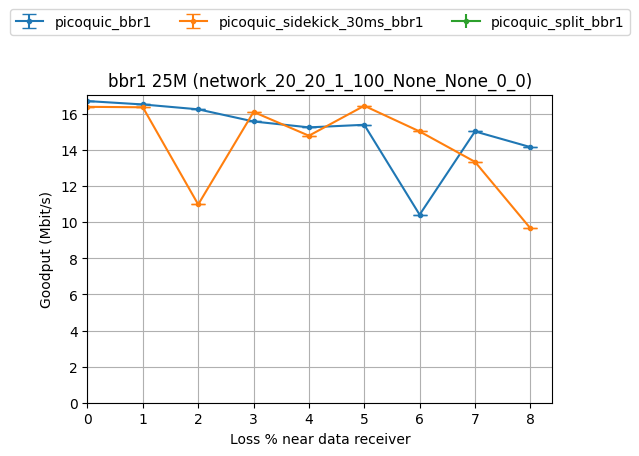

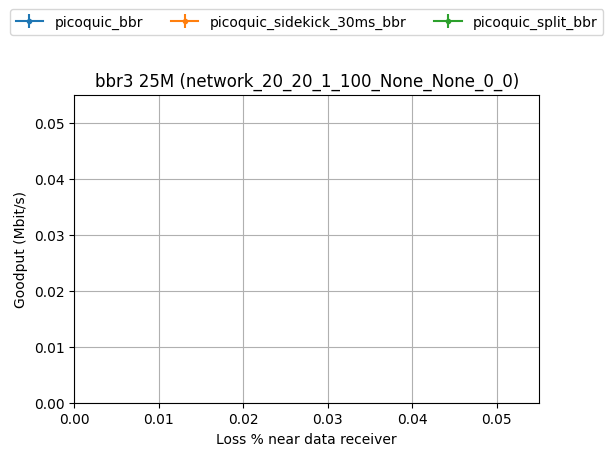

In [7]:
def plot_loss_vs_throughput(prefix, raw_data):
    title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
    ylabel = 'Goodput (Mbit/s)'
    plottable_data = PlottableData(raw_data, 'throughput_mbps')
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=ylabel)

plot_loss_vs_throughput('cubic', picoquic_raw_data)
plot_loss_vs_throughput('bbr1', bbr1_raw_data)
plot_loss_vs_throughput('bbr3', bbr3_raw_data)
# plot_loss_vs_throughput('tcp', tcp_raw_data)
# plot_loss_vs_throughput('chromium', chromium_raw_data)